<a href="https://colab.research.google.com/github/Olga-Lyt/DTA-2026/blob/main/ML/LinearRegression_DTA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Щоб результати були однаковими щоразу (відтворюваність)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

print("Бібліотеки готові ✅")

Бібліотеки готові ✅


У реальній роботі завантажте CSV через `pd.read_csv("file.csv")`.

**Генеруємо дані**  
Створюємо таблицю з ознаками й «справжньою» ціною (з невеликим випадковим шумом, як у житті).

In [2]:
n = 1000  # скільки квартир

area      = np.random.normal(60, 20, n).clip(20, 140)        # площа, м²
rooms     = np.clip(np.round(area / 25 + np.random.normal(0, 0.6, n)), 1, 5)  # кімнати
floor     = np.random.randint(1, 25, n)                      # поверх
dist_km   = np.random.exponential(5, n).clip(0.3, 25)        # відстань до центру, км
age_years = np.random.randint(0, 60, n)                      # вік будинку, років

# "Справжня" логіка ціни (у тис. $) — у житті її НЕ знаємо, модель має її відкрити:
price = (
    40                       # базова
    + area * 1.8             # кожен м² додає
    + rooms * 5              # кожна кімната
    + floor * 0.4            # трохи за поверх
    - dist_km * 3.0          # далі від центру — дешевше
    - age_years * 0.5        # старіший будинок — дешевше
    + np.random.normal(0, 12, n)   # шум: усе інше, що ми не врахували
).clip(20, None)

df = pd.DataFrame({
    "area": area.round(1),
    "rooms": rooms.astype(int),
    "floor": floor,
    "dist_km": dist_km.round(1),
    "age_years": age_years,
    "price": price.round(1),
})

df.head()

,area,rooms,floor,dist_km,age_years,price
0,69.9,4,6,2.6,14,172.1
1,57.2,3,11,6.4,30,122.8
2,73.0,3,3,2.4,54,146.3
3,90.5,3,8,3.4,13,217.6
4,55.3,3,3,2.8,10,165.2


In [3]:
df.info() # Перевірка типу даних

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   area       1000 non-null   float64
 1   rooms      1000 non-null   int64  
 2   floor      1000 non-null   int64  
 3   dist_km    1000 non-null   float64
 4   age_years  1000 non-null   int64  
 5   price      1000 non-null   float64
dtypes: float64(3), int64(3)
memory usage: 47.0 KB


In [4]:
print(f"Розмір таблиці: {df.shape[0]} рядків х {df.shape[1]} стовпців")
print("\nЧи єпропуски?")
print(df.isna().sum())
df.describe().round(2)

Розмір таблиці: 1000 рядків х 6 стовпців

Чи єпропуски?
area         0
rooms        0
floor        0
dist_km      0
age_years    0
price        0
dtype: int64


,area,rooms,floor,dist_km,age_years,price
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,60.49,2.48,12.69,4.96,30.39,136.25
std,19.33,0.95,7.00,4.71,17.23,44.99
min,20.00,1.00,1.00,0.30,0.00,20.00
25%,47.08,2.00,6.00,1.50,16.00,104.15
50%,60.50,2.00,13.00,3.60,30.00,136.75
75%,73.00,3.00,19.00,7.00,45.25,165.45
max,137.10,5.00,24.00,25.00,59.00,282.40


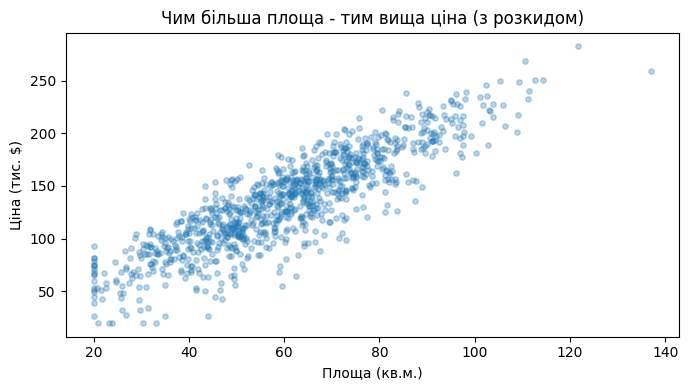

In [5]:
plt.figure(figsize=(7, 4))
plt.scatter(df['area'], df['price'], alpha=0.3, s=15)
plt.xlabel("Площа (кв.м.)")
plt.ylabel("Ціна (тис. $)")
plt.title("Чим більша площа - тим вища ціна (з розкидом)")
plt.tight_layout()
plt.show()

Розподіл даних на тестові та навчальні

In [6]:
from sklearn.model_selection import  train_test_split

X = df[['area', 'rooms', 'floor', 'dist_km', 'age_years']]  # features -  ознаки
y = df['price']  # target - ціль

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)
print("Навчальна вибірка:", X_train.shape[0], "квартир")
print("Тестова вибірка:", X_test.shape[0], "квартир")

Навчальна вибірка: 800 квартир
Тестова вибірка: 200 квартир


Лінійна регресія

In [7]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

compare = pd.DataFrame({
    "real_price": y_test[:5].round(2),
    "predict_price": y_pred[:5].round(2)
})
compare["Error"] = (compare['predict_price'] - compare['real_price']).round(2)
compare

,real_price,predict_price,Error
521,119.1,129.69,10.59
737,173.3,178.26,4.96
740,20.0,26.36,6.36
660,93.7,110.87,17.17
411,100.6,97.21,-3.39


# Аналіз помилок

МАЕ - наскільки в середньому ми помилилися в одиницях виміру (гроші)

RMSE (корінь з МАЕ) - схоже на МАЕ, сильніше карає великі промахи - менше = краще

R² - яку частину розкиду модель може оцінити - [0.;1.0] ->
ідеально, 0 - вгадує середній показник

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
# mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"МАЕ = {mae:.1f} тис. $ (у середньому помиляємося на стільки)")
# print(f"MSE = {mse:.1f}")
print(f"RMSE = {rmse:.1f} тис. $")
print(f"R² = {r2:.3f} (модель пояснює {r2 * 100:.1f}% розкиду ціни)")


МАЕ = 8.7 тис. $ (у середньому помиляємося на стільки)
RMSE = 10.8 тис. $
R² = 0.947 (модель пояснює 94.7% розкиду ціни)


In [9]:
coefs = pd.DataFrame({
    "features": X.columns,
    "coef": model.coef_.round(2)

}).sort_values("coef", key=abs, ascending=False)

print(f"Базова ціна: {model.intercept_:.2F} тис. $\n")
print(f"Як кожна ознака впливає на ціну")
coefs

Базова ціна: 40.83 тис. $

Як кожна ознака впливає на ціну


,features,coef
1,rooms,5.22
3,dist_km,-3.07
0,area,1.78
4,age_years,-0.49
2,floor,0.39


In [10]:
price2 = (
    40.83
    + area * 1.78
    + rooms * 5.22
    + dist_km * (-3.07)
    + age_years * (-0.49)
    + floor * (0.39)
)

In [11]:
# Справжня логіка ціни (у тис $) - у житті її не знаємо, модель має її відкрити:
# price = (

# 40 базова ціна

# + area * 1.78             кожен кв.м додає

# + rooms * 5.22            кожна кімната додає

# + dist_km * (-3.07)       коригування на поверх

# + age_years * (-0.49)     далі від центру - дешевше

# + floor * (0.39)          старіший будинок - дешевше

# + np.random.normal(0, 12, n)   # шум: усе інше, що ми не врахували
# ).clip(20, None) )

# Прогноз ціни нової квартири при моделі лінійної регресії


In [13]:
new_flat = pd.DataFrame([{
    'area': 60,
    'rooms': 3,
    'dist_km': 5,
    'age_years': 15,
    'floor': 3
}])

new_flat

,area,rooms,dist_km,age_years,floor
0,60,3,5,15,3


In [19]:
new_flat = pd.DataFrame([{
    'area': 60,
    'rooms': 3,
    'floor': 3, # Corrected order
    'dist_km': 5, # Corrected order
    'age_years': 15
}])
print(f"Вартість квартири становитиме: {model.predict(new_flat)[0]:.2f} тис.дол. +- {mae:.2f} тис.дол.")

Вартість квартири становитиме: 141.95 тис.дол. +- 8.66 тис.дол.
